In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [57]:
os.chdir(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES')
print(os.listdir())  # Muestra todos los archivos en el directorio actual

['df_2005.json', 'df_2005.xlsx', 'df_2025.json', 'df_caba_var.json', 'df_caba_var.xlsx', 'df_caba_var_limpio.xlsx', 'df_i_2005.json', 'df_i_2005.xlsx', 'df_i_2025.json', 'EPH_disenoreg_T1_2005.pdf', 'EPH_registro_1T2025.pdf', 'Hogar_t105.dta', 'individual_2005_2025_completo.xlsx', 'Individual_t105.dta', 'T105.txt', 'usu_hogar_T125.xlsx', 'usu_individual_T125.xlsx']


Punto 1

In [58]:
# Cargo las bases de datos
df_hogar_2005=pd.read_stata(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\Hogar_t105.dta',convert_categoricals=False)
df_hogar_2025=pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\usu_hogar_T125.xlsx')
df_i_2005=pd.read_stata(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\Individual_t105.dta',convert_categoricals=False)
df_i_2025=pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\usu_individual_T125.xlsx')

In [59]:
df_hogar_2005.head()

,CODUSU,nro_hogar,realizada,ano4,trimestre,region,mas_500,aglomerado,pondera,iv1,...,gdeccfr,pdeccfr,adeccfr,vii1_1,vii1_2,vii2_1,vii2_2,vii2_3,vii2_4,idimph
0,125082,1.0,1.0,2005.0,1.0,43.0,S,2.0,377.0,1.0,...,04,,04,2.0,0.0,98.0,0.0,0.0,0.0,00000
1,125283,1.0,1.0,2005.0,1.0,43.0,S,2.0,283.0,1.0,...,09,,09,1.0,2.0,3.0,4.0,0.0,0.0,11000
2,125409,1.0,1.0,2005.0,1.0,43.0,S,2.0,337.0,1.0,...,06,,06,2.0,0.0,1.0,0.0,0.0,0.0,00000
3,125632,1.0,1.0,2005.0,1.0,43.0,S,2.0,485.0,1.0,...,10,,10,2.0,0.0,98.0,0.0,0.0,0.0,00000
4,126192,1.0,1.0,2005.0,1.0,43.0,S,2.0,223.0,1.0,...,08,,08,2.0,0.0,98.0,0.0,0.0,0.0,00000


In [60]:
df_hogar_2005.head()

,CODUSU,nro_hogar,realizada,ano4,trimestre,region,mas_500,aglomerado,pondera,iv1,...,gdeccfr,pdeccfr,adeccfr,vii1_1,vii1_2,vii2_1,vii2_2,vii2_3,vii2_4,idimph
0,125082,1.0,1.0,2005.0,1.0,43.0,S,2.0,377.0,1.0,...,04,,04,2.0,0.0,98.0,0.0,0.0,0.0,00000
1,125283,1.0,1.0,2005.0,1.0,43.0,S,2.0,283.0,1.0,...,09,,09,1.0,2.0,3.0,4.0,0.0,0.0,11000
2,125409,1.0,1.0,2005.0,1.0,43.0,S,2.0,337.0,1.0,...,06,,06,2.0,0.0,1.0,0.0,0.0,0.0,00000
3,125632,1.0,1.0,2005.0,1.0,43.0,S,2.0,485.0,1.0,...,10,,10,2.0,0.0,98.0,0.0,0.0,0.0,00000
4,126192,1.0,1.0,2005.0,1.0,43.0,S,2.0,223.0,1.0,...,08,,08,2.0,0.0,98.0,0.0,0.0,0.0,00000


In [61]:
#df_hogar_2005.to_json(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_2025.json',orient='records',lines=True)
#df_hogar_2005.to_json(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_2005.json',orient='records',lines=True)
#df_hogar_2005.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_2005.xlsx',index=False)
#df_i_2005.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_i_2005.xlsx',index=False)
#df_i_2005.to_json(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_i_2005.json',orient='records',lines=True)
#df_i_2025.to_json(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_i_2025.json',orient='records',lines=True)
#me bajo json para ayudarme con IA's

In [62]:

# Función para normalizar nombres de columnas
def normalizar_nombres(df):
    """Normalizar nombres de columnas a mayúsculas y eliminar espacios"""
    df.columns = df.columns.str.upper().str.strip()
    return df

# Aplicar normalización a todos los dataframes
df_hogar_2005 = normalizar_nombres(df_hogar_2005)
df_hogar_2025 = normalizar_nombres(df_hogar_2025)
df_i_2005 = normalizar_nombres(df_i_2005)
df_i_2025 = normalizar_nombres(df_i_2025)

print("Nombres de columnas normalizados")

Nombres de columnas normalizados


In [63]:
# Identificar variables comunes entre años para datos de hogar
hogar_comunes = set(df_hogar_2005.columns).intersection(set(df_hogar_2025.columns))
hogar_solo_2005 = set(df_hogar_2005.columns) - set(df_hogar_2025.columns)
hogar_solo_2025 = set(df_hogar_2025.columns) - set(df_hogar_2005.columns)

print("\n--- DATOS DE HOGAR ---")
print(f"Variables comunes: {len(hogar_comunes)}")
print(f"Variables solo en 2005: {len(hogar_solo_2005)}")
print(f"Variables solo en 2025: {len(hogar_solo_2025)}")

# Identificar variables comunes entre años para datos individuales
individual_comunes = set(df_i_2005.columns).intersection(set(df_i_2025.columns))
individual_solo_2005 = set(df_i_2005.columns) - set(df_i_2025.columns)
individual_solo_2025 = set(df_i_2025.columns) - set(df_i_2005.columns)

print("\n--- DATOS INDIVIDUALES ---")
print(f"Variables comunes: {len(individual_comunes)}")
print(f"Variables solo en 2005: {len(individual_solo_2005)}")
print(f"Variables solo en 2025: {len(individual_solo_2025)}")

# Mostrar algunas variables clave comunes
print("\nAlgunas variables comunes en hogar:")
print(sorted(list(hogar_comunes))[:10])

print("\nAlgunas variables comunes en individual:")
print(sorted(list(individual_comunes))[:10])


--- DATOS DE HOGAR ---
Variables comunes: 83
Variables solo en 2005: 5
Variables solo en 2025: 15

--- DATOS INDIVIDUALES ---
Variables comunes: 168
Variables solo en 2005: 8
Variables solo en 2025: 67

Algunas variables comunes en hogar:
['ADECCFR', 'ADECIFR', 'AGLOMERADO', 'ANO4', 'CODUSU', 'DECCFR', 'DECIFR', 'GDECCFR', 'GDECIFR', 'IDECCFR']

Algunas variables comunes en individual:
['ADECCFR', 'ADECIFR', 'ADECINDR', 'ADECOCUR', 'AGLOMERADO', 'ANO4', 'CAT_INAC', 'CAT_OCUP', 'CH03', 'CH04']


Solo debo mergear las individuales

In [64]:
# Primero, asegurémonos de que tenemos las variables clave para el merge
print("Variables en individual 2005:", df_i_2005.columns.tolist()[:10])
print("Variables en individual 2025:", df_i_2025.columns.tolist()[:10])

# Identificar variables comunes para el merge
variables_comunes = set(df_i_2005.columns).intersection(set(df_i_2025.columns))
print(f"\nVariables comunes para merge: {len(variables_comunes)}")
print("Algunas variables comunes:", sorted(list(variables_comunes))[:10])

Variables en individual 2005: ['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'ANO4', 'TRIMESTRE', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA']
Variables en individual 2025: ['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA']

Variables comunes para merge: 168
Algunas variables comunes: ['ADECCFR', 'ADECIFR', 'ADECINDR', 'ADECOCUR', 'AGLOMERADO', 'ANO4', 'CAT_INAC', 'CAT_OCUP', 'CH03', 'CH04']


In [65]:
# Agregar un identificador de año a cada dataframe antes del merge
df_i_2005['AÑO'] = 2005
df_i_2025['AÑO'] = 2025

print("Añadida columna de año a ambos datasets")

Añadida columna de año a ambos datasets


In [66]:
# Verificar las variables clave para el merge
variables_clave = ['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'AÑO']

for var in variables_clave:
    print(f"{var} - 2005: {df_i_2005[var].dtype}, 2025: {df_i_2025[var].dtype}")

    # Mostrar algunos valores únicos para comparar
    if var in ['CODUSU']:  # Para variables con muchos valores únicos
        print(f"  Ejemplos 2005: {df_i_2005[var].iloc[:3].tolist()}")
        print(f"  Ejemplos 2025: {df_i_2025[var].iloc[:3].tolist()}")
    else:
        print(f"  Valores únicos 2005: {sorted(df_i_2005[var].unique())[:5]}")
        print(f"  Valores únicos 2025: {sorted(df_i_2025[var].unique())[:5]}")
    print()

CODUSU - 2005: object, 2025: object
  Ejemplos 2005: ['125098  ', '125188  ', '125188  ']
  Ejemplos 2025: ['TQRMNOVQVHJOLOCDEFKID00875778', 'TQRMNOVQVHJOLOCDEFKID00875778', 'TQRMNOVQVHJOLOCDEFKID00875778']

NRO_HOGAR - 2005: float64, 2025: int64
  Valores únicos 2005: [1.0, 2.0, 3.0, 4.0, 5.0]
  Valores únicos 2025: [1, 2, 3, 4, 51]

COMPONENTE - 2005: float64, 2025: int64
  Valores únicos 2005: [1.0, 2.0, 3.0, 4.0, 5.0]
  Valores únicos 2025: [1, 2, 3, 4, 5]

AÑO - 2005: int64, 2025: int64
  Valores únicos 2005: [2005]
  Valores únicos 2025: [2025]



In [67]:
df_i_2005.info(verbose=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47030 entries, 0 to 47029
Data columns (total 177 columns):
 #    Column      Dtype  
---   ------      -----  
 0    CODUSU      object 
 1    NRO_HOGAR   float64
 2    COMPONENTE  float64
 3    H15         float64
 4    ANO4        float64
 5    TRIMESTRE   float64
 6    REGION      float64
 7    MAS_500     object 
 8    AGLOMERADO  float64
 9    PONDERA     float64
 10   CH03        float64
 11   CH04        float64
 12   CH06        float64
 13   CH07        float64
 14   CH08        float64
 15   CH09        float64
 16   CH10        float64
 17   CH11        float64
 18   CH12        float64
 19   CH13        float64
 20   CH14        object 
 21   CH15        float64
 22   CH15_COD    object 
 23   CH16        float64
 24   CH16_COD    object 
 25   NIVEL_ED    float64
 26   ESTADO      float64
 27   CAT_OCUP    float64
 28   CAT_INAC    float64
 29   PP02C1      float64
 30   PP02C2      float64
 31   PP02C3      float64
 32   

In [68]:
df_i_2025.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45425 entries, 0 to 45424
Data columns (total 236 columns):
 #    Column      Dtype  
---   ------      -----  
 0    CODUSU      object 
 1    ANO4        int64  
 2    TRIMESTRE   int64  
 3    NRO_HOGAR   int64  
 4    COMPONENTE  int64  
 5    H15         int64  
 6    REGION      int64  
 7    MAS_500     object 
 8    AGLOMERADO  int64  
 9    PONDERA     int64  
 10   CH03        int64  
 11   CH04        int64  
 12   CH05        object 
 13   CH06        int64  
 14   CH07        int64  
 15   CH08        float64
 16   CH09        int64  
 17   CH10        int64  
 18   CH11        int64  
 19   CH12        int64  
 20   CH13        int64  
 21   CH14        float64
 22   CH15        int64  
 23   CH15_COD    float64
 24   CH16        int64  
 25   CH16_COD    float64
 26   NIVEL_ED    int64  
 27   ESTADO      int64  
 28   CAT_OCUP    int64  
 29   CAT_INAC    int64  
 30   IMPUTA      float64
 31   PP02C1      int64  
 32   

In [69]:
# Como son datos de diferentes años, lo apropiado es concatenar en lugar de merge
df_individual_completo = pd.concat([df_i_2005, df_i_2025],
                                   ignore_index=True, sort=False)

print(f"Dataset combinado: {df_individual_completo.shape}")
print(f"Años en dataset combinado: {sorted(df_individual_completo['AÑO'].unique())}")

Dataset combinado: (92455, 244)
Años en dataset combinado: [2005, 2025]


In [70]:
df_individual_completo.info(verbose=True)
df_individual_completo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92455 entries, 0 to 92454
Data columns (total 244 columns):
 #    Column      Dtype  
---   ------      -----  
 0    CODUSU      object 
 1    NRO_HOGAR   float64
 2    COMPONENTE  float64
 3    H15         float64
 4    ANO4        float64
 5    TRIMESTRE   float64
 6    REGION      float64
 7    MAS_500     object 
 8    AGLOMERADO  float64
 9    PONDERA     float64
 10   CH03        float64
 11   CH04        float64
 12   CH06        float64
 13   CH07        float64
 14   CH08        float64
 15   CH09        float64
 16   CH10        float64
 17   CH11        float64
 18   CH12        float64
 19   CH13        float64
 20   CH14        object 
 21   CH15        float64
 22   CH15_COD    object 
 23   CH16        float64
 24   CH16_COD    object 
 25   NIVEL_ED    float64
 26   ESTADO      float64
 27   CAT_OCUP    float64
 28   CAT_INAC    float64
 29   PP02C1      float64
 30   PP02C2      float64
 31   PP02C3      float64
 32   

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,125098,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1017.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,125188,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,125188,1.0,2.0,1.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,125188,1.0,3.0,0.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,125242,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92450,TQRMNOPWQHLMKUCDEGJBF00852927,1.0,4.0,1.0,2025.0,1.0,43.0,S,13.0,773.0,...,0.0,0.0,0.0,0.0,8.0,8.0,8.0,NaN,8.0,8.0
92451,TQRMNOPWQHLMKUCDEGJBF00852927,1.0,5.0,0.0,2025.0,1.0,43.0,S,13.0,773.0,...,0.0,0.0,0.0,0.0,8.0,8.0,8.0,NaN,8.0,8.0
92452,TQRMNOSSVHLMLMCDEGJBF00852929,1.0,1.0,1.0,2025.0,1.0,43.0,S,13.0,719.0,...,0.0,0.0,0.0,0.0,10.0,10.0,10.0,NaN,10.0,10.0
92453,TQRMNOSSXHLMLMCDEGJBF00858297,2.0,1.0,1.0,2025.0,1.0,43.0,S,13.0,519.0,...,0.0,0.0,0.0,0.0,10.0,10.0,10.0,NaN,10.0,10.0


In [71]:
# Verificar la distribución por año
distribucion_año = df_individual_completo['AÑO'].value_counts()
print("Distribución por año:")
print(distribucion_año)

# Verificar valores missing en variables clave
print("\nValores missing en variables clave:")
for var in variables_clave:
    missing = df_individual_completo[var].isnull().sum()
    print(f"{var}: {missing} valores missing ({missing/len(df_individual_completo)*100:.2f}%)")

Distribución por año:
AÑO
2005    47030
2025    45425
Name: count, dtype: int64

Valores missing en variables clave:
CODUSU: 0 valores missing (0.00%)
NRO_HOGAR: 0 valores missing (0.00%)
COMPONENTE: 0 valores missing (0.00%)
AÑO: 0 valores missing (0.00%)


In [72]:
# Guardar la base combinada
#df_individual_completo.to_excel('individual_2005_2025_completo.xlsx', index=False)
#print("Base individual combinada guardada como 'individual_2005_2025_completo.xlsx'")

# También guardar en formato Parquet para mejor eficiencia
#df_individual_completo.to_parquet('individual_2005_2025_completo.parquet', index=False)
#print("Base individual combinada guardada como 'individual_2005_2025_completo.parquet'")

In [73]:
# === Unificar tipos de variables antes de concatenar ===

variables_interes = [
    'CH04', 'CH06', 'CH07', 'CH08',
    'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF',
    'CH10', 'CH11', 'CH12', 'CH15',
    'EMPLEO', 'PP02B', 'PP02E'
]

# Definir tipos: numéricas vs categóricas
numericas = ['CH06', 'IPCF']
categ_str = [v for v in variables_interes if v not in numericas]

# Convertir en ambos dataframes (2005 y 2025), solo si existe la columna
for col in numericas:
    if col in df_i_2005.columns:
        df_i_2005[col] = pd.to_numeric(df_i_2005[col], errors="coerce")
    if col in df_i_2025.columns:
        df_i_2025[col] = pd.to_numeric(df_i_2025[col], errors="coerce")

for col in categ_str:
    if col in df_i_2005.columns:
        df_i_2005[col] = df_i_2005[col].astype("Float64")
    if col in df_i_2025.columns:
        df_i_2025[col] = df_i_2025[col].astype("Float64")


In [74]:
print("Columnas 2005:", df_i_2005.columns.tolist())
print("Columnas 2025:", df_i_2025.columns.tolist())


Columnas 2005: ['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'ANO4', 'TRIMESTRE', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP08J

In [75]:
print("Columnas 2005:", df_i_2005.columns.tolist())
print("Columnas 2025:", df_i_2025.columns.tolist())

faltan_2005 = [v for v in variables_interes if v not in df_i_2005.columns]
faltan_2025 = [v for v in variables_interes if v not in df_i_2025.columns]

print("\nVariables faltantes en 2005:", faltan_2005)
print("Variables faltantes en 2025:", faltan_2025)


Columnas 2005: ['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'ANO4', 'TRIMESTRE', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP08F1', 'PP08F2', 'PP08J1', 'PP08J

In [76]:
# === Concatenar bases 2005 y 2025 ===
df_individual_completo = pd.concat([df_i_2005, df_i_2025],
                                   ignore_index=True, sort=False)

# Renombrar columna de año para que sea consistente
df_individual_completo = df_individual_completo.rename(columns={"AÑO": "anio"})

print(f"Dataset combinado: {df_individual_completo.shape}")
print(f"Años en dataset combinado: {sorted(df_individual_completo['anio'].unique())}")


Dataset combinado: (92455, 244)
Años en dataset combinado: [2005, 2025]


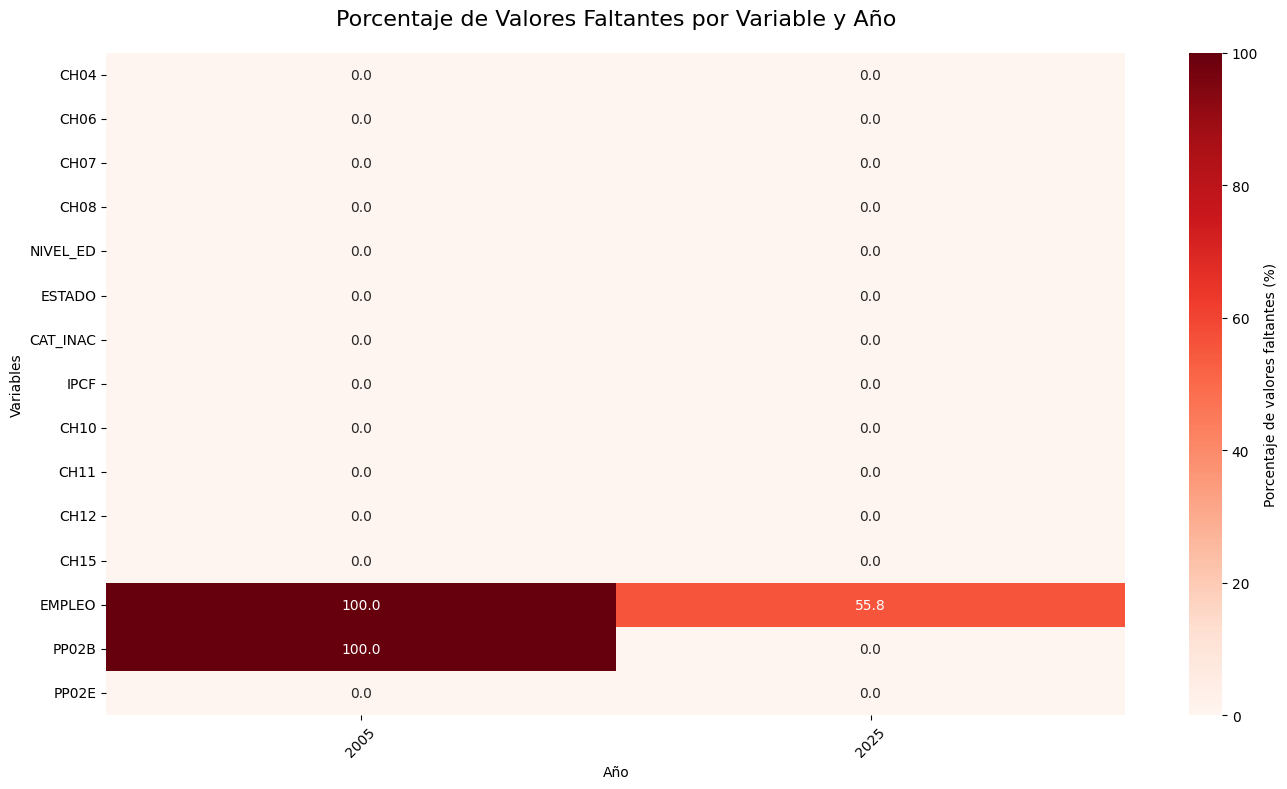

Resumen de valores faltantes:

Año 2005:
--------------------
  EMPLEO: 100.0% faltantes
  PP02B: 100.0% faltantes

Año 2025:
--------------------
  EMPLEO: 55.8% faltantes


In [77]:
# === Heatmap de valores faltantes por variable y año ===
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo las variables de interés + año
df_variables_interes = df_individual_completo[variables_interes + ['anio']].copy()

# Calcular porcentaje de faltantes por año
faltantes_por_anio = df_variables_interes.groupby('anio').apply(
    lambda x: x.isnull().sum() / len(x) * 100
).drop(columns=['anio'])

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(faltantes_por_anio.T,
            annot=True,
            fmt='.1f',
            cmap='Reds',
            cbar_kws={'label': 'Porcentaje de valores faltantes (%)'})
plt.title('Porcentaje de Valores Faltantes por Variable y Año', fontsize=16, pad=20)
plt.xlabel('Año')
plt.ylabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Resumen de faltantes
print("Resumen de valores faltantes:")
print("=" * 50)
for anio in faltantes_por_anio.index:
    print(f"\nAño {int(anio)}:")
    print("-" * 20)
    variables_con_faltantes = faltantes_por_anio.loc[anio][faltantes_por_anio.loc[anio] > 5]
    if not variables_con_faltantes.empty:
        for var, porcentaje in variables_con_faltantes.items():
            print(f"  {var}: {porcentaje:.1f}% faltantes")
    else:
        print("  Todas las variables tienen menos del 5% de valores faltantes")


punto b)

In [78]:
# nos quedamos con el sector de nuestro interes
df_caba = df_individual_completo[df_individual_completo['AGLOMERADO'] == 32].copy()
df_caba

,CODUSU,NRO_HOGAR,COMPONENTE,H15,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,125098,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1017.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,125188,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,125188,1.0,2.0,1.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,125188,1.0,3.0,0.0,2005.0,1.0,1.0,S,32.0,1062.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,125242,1.0,1.0,1.0,2005.0,1.0,1.0,S,32.0,1103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,TQRMNORXPHMKMNCDEIIAD00882460,1.0,3.0,1.0,2025.0,1.0,1.0,S,32.0,1327.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,1.0
92011,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,1.0,1.0,2025.0,1.0,1.0,S,32.0,819.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
92012,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,2.0,1.0,2025.0,1.0,1.0,S,32.0,819.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
92013,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,3.0,1.0,2025.0,1.0,1.0,S,32.0,819.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
df_caba_var = df_caba[['NRO_HOGAR','CODUSU','CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'ANO4', 'CH10', 'CH11', 'CH12', 'CH15', 'EMPLEO', 'PP02B', 'PP02E']].copy()
df_caba_var

,NRO_HOGAR,CODUSU,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,ANO4,CH10,CH11,CH12,CH15,EMPLEO,PP02B,PP02E
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,<NA>,<NA>,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,<NA>,<NA>,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,<NA>,<NA>,0.0
3,1.0,125188,2.0,-1.0,5.0,4.0,7.0,4.0,5.0,150.00,2005.0,0.0,0.0,0.0,1.0,<NA>,<NA>,0.0
4,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,<NA>,<NA>,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,<NA>,0.0,0.0
92011,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,<NA>,0.0,0.0
92012,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,<NA>,1.0,0.0
92013,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


In [80]:
df_caba_var[['EMPLEO','PP02B']] = df_caba[['EMPLEO','PP02B']].fillna(0)
df_caba_var

,NRO_HOGAR,CODUSU,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,ANO4,CH10,CH11,CH12,CH15,EMPLEO,PP02B,PP02E
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,0.0,0.0,0.0
3,1.0,125188,2.0,-1.0,5.0,4.0,7.0,4.0,5.0,150.00,2005.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0
92011,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
92012,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,1.0,0.0
92013,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


Ahora ya tenemos la matriz filtrada por CABA y con las variables de nuestro interes CH10	CH11	CH12	CH15	EMPLEO	PP02B	PP02E

A Limpiar la matriz

La variable empleo tiene muchos missing values entonces lo que hago es agregarle 0 en esos elementos vacios

In [81]:
df_caba_var.to_excel('df_caba_var.xlsx', index=False)
df_caba_var.to_json('df_caba_var.json', orient='records', lines=True)

Ahora vamos a cambiar el nombre de las columnas para la sencilla interpretacion

In [82]:
# Diccionario: nombre_actual -> nombre_nuevo
nuevos_nombres = {
    'CH04': 'genero',
    'CH06': 'edad',
    'CH07': 'tipo_empleo',
    'CH08': 'parentesco',
    'NIVEL_ED': 'nivel_educ',
    'ESTADO': 'estado_empleo',
    'CAT_INAC': 'categoria_inactividad',
    'IPCF': 'ingreso_per_capita',
    'ANO4': 'anio',
    'CH10': 'tipo_cobertura_salud',
    'CH11': 'obra_social',
    'CH12': 'nivel_ocupacion',
    'CH15': 'tipo_contrato',
    'EMPLEO': 'empleo',
    'PP02B': 'busqueda_empleo',
    'PP02E': 'medio_busqueda_empleo',
    'CODUSU':'Distincion_vivienda_individuo',
    'NRO_HOGAR':'Distincion_vivienda_hogar'
}

df_caba_var = df_caba_var.rename(columns=nuevos_nombres)

In [83]:
df_caba_var

,Distincion_vivienda_hogar,Distincion_vivienda_individuo,genero,edad,tipo_empleo,parentesco,nivel_educ,estado_empleo,categoria_inactividad,ingreso_per_capita,anio,tipo_cobertura_salud,obra_social,nivel_ocupacion,tipo_contrato,empleo,busqueda_empleo,medio_busqueda_empleo
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,0.0,0.0,0.0
3,1.0,125188,2.0,-1.0,5.0,4.0,7.0,4.0,5.0,150.00,2005.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0
92011,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
92012,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,1.0,0.0
92013,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


In [84]:
# Limpieza concisa de valores sin sentido
def limpiar_valores_eph(df_caba_var):
    """
    Corrige valores sin sentido según documentación EPH
    """
    # Ingresos no positivos → NaN
    df_caba_var['ingreso_per_capita'] = np.where(df_caba_var['ingreso_per_capita'] <= 0, np.nan, df_caba_var['ingreso_per_capita'])

    # Edades fuera de rango [0, 120] → NaN
    df_caba_var['edad'] = np.where((df_caba_var['edad'] < 0) | (df_caba_var['edad'] > 120), np.nan, df_caba_var['edad'])

    # Variables categóricas con valores fuera de rango → NaN
    variables_categoricas = {
        'genero': [1, 2],
        'estado_empleo': [1, 2, 3, 4],
        'nivel_educ': [1, 2, 3, 4, 5, 6, 7],
        'parentesco': list(range(1, 13))
    }

    for var, valores_validos in variables_categoricas.items():
        df_caba_var[var] = np.where(df_caba_var[var].isin(valores_validos), df_caba_var[var], np.nan)

    return df_caba_var

# Aplicar limpieza
df_limpio = limpiar_valores_eph(df_caba_var.copy())

# Estadísticas de limpieza
print("Valores reemplazados por NaN:")
for col in df_limpio.columns:
    original_count = df_caba_var[col].count()
    limpio_count = df_limpio[col].count()
    if original_count != limpio_count:
        perdida = original_count - limpio_count
        print(f"{col}: {perdida} valores ({perdida/len(df_limpio)*100:.1f}%)")

Valores reemplazados por NaN:
edad: 29 valores (0.8%)
parentesco: 5 valores (0.1%)
estado_empleo: 8 valores (0.2%)
ingreso_per_capita: 546 valores (14.4%)


In [85]:
# Eliminar filas donde 'edad' es NaN
df_limpio = df_limpio.dropna(subset=['edad'])

# Verificar que no quedan valores nulos en 'edad'
print(f"Valores nulos en 'edad': {df_limpio['edad'].isnull().sum()}")

Valores nulos en 'edad': 0


In [86]:
df_limpio[['empleo','busqueda_empleo','ingreso_per_capita']] = df_limpio[['empleo','busqueda_empleo','ingreso_per_capita']].fillna(0)
df_limpio

,Distincion_vivienda_hogar,Distincion_vivienda_individuo,genero,edad,tipo_empleo,parentesco,nivel_educ,estado_empleo,categoria_inactividad,ingreso_per_capita,anio,tipo_cobertura_salud,obra_social,nivel_ocupacion,tipo_contrato,empleo,busqueda_empleo,medio_busqueda_empleo
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,0.0,0.0,0.0
4,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
5,1.0,125436,1.0,54.0,2.0,1.0,4.0,1.0,0.0,1016.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0
92011,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
92012,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,1.0,0.0
92013,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


In [87]:
df_limpio.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 92014
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Distincion_vivienda_hogar      3774 non-null   float64
 1   Distincion_vivienda_individuo  3774 non-null   object 
 2   genero                         3774 non-null   object 
 3   edad                           3774 non-null   float64
 4   tipo_empleo                    3774 non-null   Float64
 5   parentesco                     3769 non-null   object 
 6   nivel_educ                     3774 non-null   object 
 7   estado_empleo                  3766 non-null   object 
 8   categoria_inactividad          3774 non-null   Float64
 9   ingreso_per_capita             3774 non-null   float64
 10  anio                           3774 non-null   float64
 11  tipo_cobertura_salud           3774 non-null   Float64
 12  obra_social                    3774 non-null   Float

In [88]:
df_limpio

,Distincion_vivienda_hogar,Distincion_vivienda_individuo,genero,edad,tipo_empleo,parentesco,nivel_educ,estado_empleo,categoria_inactividad,ingreso_per_capita,anio,tipo_cobertura_salud,obra_social,nivel_ocupacion,tipo_contrato,empleo,busqueda_empleo,medio_busqueda_empleo
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,0.0,0.0,0.0
4,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
5,1.0,125436,1.0,54.0,2.0,1.0,4.0,1.0,0.0,1016.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92010,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0
92011,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
92012,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,1.0,0.0
92013,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


Limpio! punto c)

In [89]:
df_limpio.reset_index(drop=True, inplace=True)
df_limpio

,Distincion_vivienda_hogar,Distincion_vivienda_individuo,genero,edad,tipo_empleo,parentesco,nivel_educ,estado_empleo,categoria_inactividad,ingreso_per_capita,anio,tipo_cobertura_salud,obra_social,nivel_ocupacion,tipo_contrato,empleo,busqueda_empleo,medio_busqueda_empleo
0,1.0,125098,1.0,80.0,4.0,1.0,3.0,3.0,1.0,583.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
1,1.0,125188,1.0,26.0,2.0,4.0,4.0,1.0,0.0,150.00,2005.0,2.0,0.0,4.0,2.0,0.0,0.0,0.0
2,1.0,125188,2.0,27.0,2.0,4.0,6.0,3.0,4.0,150.00,2005.0,2.0,0.0,6.0,1.0,0.0,0.0,0.0
3,1.0,125242,2.0,71.0,4.0,1.0,2.0,3.0,1.0,855.00,2005.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
4,1.0,125436,1.0,54.0,2.0,1.0,4.0,1.0,0.0,1016.00,2005.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,1.0,TQRMNORXPHMKMNCDEIIAD00882460,2.0,12.0,5.0,4.0,3.0,3.0,3.0,73333.33,2025.0,1.0,1.0,4.0,1.0,0.0,0.0,0.0
3770,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,1.0,76.0,4.0,1.0,3.0,3.0,1.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,0.0,0.0
3771,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,49.0,1.0,4.0,4.0,2.0,0.0,0.00,2025.0,2.0,0.0,4.0,1.0,0.0,1.0,0.0
3772,1.0,TQRMNOPUTHMKMPCDEIIAD00882461,2.0,48.0,5.0,4.0,6.0,1.0,0.0,0.00,2025.0,2.0,0.0,6.0,1.0,2.0,0.0,0.0


In [90]:
df_limpio.to_excel('df_caba_var_limpio.xlsx', index=False)

---


punto opcional d)

In [91]:
df_hogar05 = df_hogar_2005[['NRO_HOGAR','CODUSU','IV1', 'IV2', 'IV6', 'IV8', 'II8']].copy()
df_hogar25 = df_hogar_2025[['NRO_HOGAR','CODUSU','IV1', 'IV2', 'IV6', 'IV8', 'II8']].copy()

df_hogar05


,NRO_HOGAR,CODUSU,IV1,IV2,IV6,IV8,II8
0,1.0,125082,1.0,4.0,1.0,1.0,1.0
1,1.0,125283,1.0,3.0,1.0,1.0,1.0
2,1.0,125409,1.0,6.0,1.0,1.0,1.0
3,1.0,125632,1.0,3.0,1.0,1.0,1.0
4,1.0,126192,1.0,4.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...
13592,1.0,285584,1.0,6.0,1.0,1.0,1.0
13593,1.0,285787,1.0,1.0,1.0,1.0,1.0
13594,1.0,288074,1.0,4.0,1.0,1.0,1.0
13595,1.0,288189,1.0,4.0,1.0,1.0,2.0


In [92]:
df_hogar25

,NRO_HOGAR,CODUSU,IV1,IV2,IV6,IV8,II8
0,1,TQRMNOQVSHKOLNCDEGGFB00858441,1,4,1,1,2
1,1,TQSMNORTSHMOLTCDEGGFB00877605,1,3,1,1,1
2,1,TQRMNOQQXHMMMLCDEGGFB00877606,1,2,1,1,1
3,1,TQRMNOTTWHMMLOCDEFIAH00877819,1,2,1,1,1
4,2,TQRMNORQQHLMKOCDEHIBB00853810,1,1,1,1,2
...,...,...,...,...,...,...,...
15979,1,TQRMNOSXVHJMLOCDEGGFB00875746,1,3,1,1,1
15980,1,TQRMNOQVQHLMLOCDEGGFB00852621,1,3,1,1,1
15981,1,TQRMNOSVYHKOLMCDEGGFB00860046,1,3,1,1,2
15982,1,TQRMNOQWQHJNLRCDEGGFB00875615,1,2,1,1,1


ahora mergeemos por todos lados y veamos que obtenemos

In [93]:
#limpiamos valores perdidos
df_hogar25[['IV1','IV2','IV6','IV8','II8']] = df_hogar25[['IV1','IV2','IV6','IV8','II8']].fillna(0)
df_hogar25

,NRO_HOGAR,CODUSU,IV1,IV2,IV6,IV8,II8
0,1,TQRMNOQVSHKOLNCDEGGFB00858441,1,4,1,1,2
1,1,TQSMNORTSHMOLTCDEGGFB00877605,1,3,1,1,1
2,1,TQRMNOQQXHMMMLCDEGGFB00877606,1,2,1,1,1
3,1,TQRMNOTTWHMMLOCDEFIAH00877819,1,2,1,1,1
4,2,TQRMNORQQHLMKOCDEHIBB00853810,1,1,1,1,2
...,...,...,...,...,...,...,...
15979,1,TQRMNOSXVHJMLOCDEGGFB00875746,1,3,1,1,1
15980,1,TQRMNOQVQHLMLOCDEGGFB00852621,1,3,1,1,1
15981,1,TQRMNOSVYHKOLMCDEGGFB00860046,1,3,1,1,2
15982,1,TQRMNOQWQHJNLRCDEGGFB00875615,1,2,1,1,1


In [94]:
df_hogar05[['IV1','IV2','IV6','IV8','II8']] = df_hogar05[['IV1','IV2','IV6','IV8','II8']].fillna(0)
df_hogar05

,NRO_HOGAR,CODUSU,IV1,IV2,IV6,IV8,II8
0,1.0,125082,1.0,4.0,1.0,1.0,1.0
1,1.0,125283,1.0,3.0,1.0,1.0,1.0
2,1.0,125409,1.0,6.0,1.0,1.0,1.0
3,1.0,125632,1.0,3.0,1.0,1.0,1.0
4,1.0,126192,1.0,4.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...
13592,1.0,285584,1.0,6.0,1.0,1.0,1.0
13593,1.0,285787,1.0,1.0,1.0,1.0,1.0
13594,1.0,288074,1.0,4.0,1.0,1.0,1.0
13595,1.0,288189,1.0,4.0,1.0,1.0,2.0


In [95]:
#mergeamos 2005 2025
df_hogar = pd.concat([df_hogar05, df_hogar25], axis=0)

In [96]:
nuevos_nombres = {
    'IV1':'Tipo_de_vivienda',
    'IV2':'ambientes',
    'IV6':'agua',
    'IV8':'baño',
    'II8':'gas',
    'CODUSU':'Distincion_vivienda_individuo',
    'NRO_HOGAR':'Distincion_vivienda_hogar'
}

df_hogar = df_hogar.rename(columns=nuevos_nombres)

In [97]:
def realizar_uniones(df_limpio, df_hogar):
    """
    Realiza los cuatro tipos de uniones entre las bases
    """
    # Verificar que las columnas de unión existen en ambos DataFrames
    columnas_union = ['Distincion_vivienda_individuo', 'Distincion_vivienda_hogar'] #antes: ['CODUSU', 'NRO_HOGAR']

    for col in columnas_union:
        if col not in df_limpio.columns:
            print(f"Advertencia: Columna {col} no encontrada en df_limpio")
            return None, None, None, None
        if col not in df_hogar.columns:
            print(f"Advertencia: Columna {col} no encontrada en df_hogar")
            return None, None, None, None

    # Inner join - solo coincidencias perfectas
    inner_join = pd.merge(
        df_limpio,
        df_hogar,
        on=columnas_union,
        how='inner',
        suffixes=('_ind', '_hogar')
    )

    # Left join - mantiene todos los individuos
    left_join = pd.merge(
        df_limpio,
        df_hogar,
        on=columnas_union,
        how='left',
        suffixes=('_ind', '_hogar')
    )

    # Right join - mantiene todos los hogares
    right_join = pd.merge(
        df_limpio,
        df_hogar,
        on=columnas_union,
        how='right',
        suffixes=('_ind', '_hogar')
    )

    # Full join - mantiene todos los registros
    full_join = pd.merge(
        df_limpio,
        df_hogar,
        on=columnas_union,
        how='outer',
        suffixes=('_ind', '_hogar')
    )

    print(f"Uniones completadas:")
    print(f"- Inner join: {inner_join.shape[0]} registros")
    print(f"- Left join: {left_join.shape[0]} registros")
    print(f"- Right join: {right_join.shape[0]} registros")
    print(f"- Full join: {full_join.shape[0]} registros")

    return inner_join, left_join, right_join, full_join

# Realizar las uniones
inner_data, left_data, right_data, full_data = realizar_uniones(df_limpio, df_hogar)

Uniones completadas:
- Inner join: 3774 registros
- Left join: 3774 registros
- Right join: 31815 registros
- Full join: 31815 registros


In [98]:
def analizar_merges(inner_data, left_data, right_data, full_data):
    """
    Analiza y muestra estadísticas de los cuatro tipos de merge
    """
    print("=" * 60)
    print("ANÁLISIS DE LOS MERGES REALIZADOS")
    print("=" * 60)

    # Diccionario con los merges y sus nombres
    merges = {
        'INNER JOIN': inner_data,
        'LEFT JOIN': left_data,
        'RIGHT JOIN': right_data,
        'FULL JOIN': full_data
    }

    resultados = []

    for nombre, df in merges.items():
        if df is not None:
            # Calcular estadísticas
            filas = df.shape[0]
            columnas = df.shape[1]
            total_valores = filas * columnas
            missing_values = df.isnull().sum().sum()
            porcentaje_missing = (missing_values / total_valores) * 100 if total_valores > 0 else 0

            resultados.append({
                'Tipo de Merge': nombre,
                'Filas': filas,
                'Columnas': columnas,
                'Missing Values': missing_values,
                '% Missing': f"{porcentaje_missing:.2f}%"
            })

            # Mostrar información detallada
            print(f"\n{nombre}:")
            print(f"  • Filas: {filas:,}")
            print(f"  • Columnas: {columnas}")
            print(f"  • Missing Values: {missing_values:,}")
            print(f"  • % Missing: {porcentaje_missing:.2f}%")

            # Mostrar las columnas con más missing values (top 5)
            if missing_values > 0:
                missing_por_columna = df.isnull().sum().sort_values(ascending=False)
                top_5_missing = missing_por_columna[missing_por_columna > 0].head(5)
                if len(top_5_missing) > 0:
                    print("  • Top 5 columnas con missing values:")
                    for col, count in top_5_missing.items():
                        porcentaje_col = (count / filas) * 100
                        print(f"    - {col}: {count:,} ({porcentaje_col:.1f}%)")
        else:
            print(f"\n{nombre}: No disponible")

    # Crear DataFrame resumen
    df_resumen = pd.DataFrame(resultados)

    print("\n" + "=" * 60)
    print("RESUMEN COMPARATIVO")
    print("=" * 60)
    print(df_resumen.to_string(index=False))

    return df_resumen

# Ejecutar el análisis
print("Analizando los merges realizados...")
resumen_merges = analizar_merges(inner_data, left_data, right_data, full_data)

# Análisis adicional comparativo
print("\n" + "=" * 60)
print("ANÁLISIS COMPARATIVO ADICIONAL")
print("=" * 60)

if all(x is not None for x in [inner_data, left_data, right_data, full_data]):
    print(f"Filas en df_limpio (individual): {df_limpio.shape[0]:,}")
    print(f"Filas en df_hogar (hogar): {df_hogar.shape[0]:,}")
    print(f"Coincidencias perfectas (INNER): {inner_data.shape[0]:,}")
    print(f"Individuos sin hogar (LEFT only): {left_data.shape[0] - inner_data.shape[0]:,}")
    print(f"Hogares sin individuos (RIGHT only): {right_data.shape[0] - inner_data.shape[0]:,}")

    # Calcular porcentaje de coincidencia
    coincidencia_porcentaje = (inner_data.shape[0] / min(df_limpio.shape[0], df_hogar.shape[0])) * 100
    print(f"Porcentaje de coincidencia: {coincidencia_porcentaje:.1f}%")

Analizando los merges realizados...
ANÁLISIS DE LOS MERGES REALIZADOS

INNER JOIN:
  • Filas: 3,774
  • Columnas: 23
  • Missing Values: 13
  • % Missing: 0.01%
  • Top 5 columnas con missing values:
    - estado_empleo: 8 (0.2%)
    - parentesco: 5 (0.1%)

LEFT JOIN:
  • Filas: 3,774
  • Columnas: 23
  • Missing Values: 13
  • % Missing: 0.01%
  • Top 5 columnas con missing values:
    - estado_empleo: 8 (0.2%)
    - parentesco: 5 (0.1%)

RIGHT JOIN:
  • Filas: 31,815
  • Columnas: 23
  • Missing Values: 448,669
  • % Missing: 61.31%
  • Top 5 columnas con missing values:
    - estado_empleo: 28,049 (88.2%)
    - parentesco: 28,046 (88.2%)
    - tipo_cobertura_salud: 28,041 (88.1%)
    - anio: 28,041 (88.1%)
    - medio_busqueda_empleo: 28,041 (88.1%)

FULL JOIN:
  • Filas: 31,815
  • Columnas: 23
  • Missing Values: 448,669
  • % Missing: 61.31%
  • Top 5 columnas con missing values:
    - estado_empleo: 28,049 (88.2%)
    - parentesco: 28,046 (88.2%)
    - tipo_cobertura_salud: 28,0

Punto 1 finalizado

Parte II: Primer Análisis Exploratorio


Inciso 3 — Conteos por sexo


ANO4,2005,2025
SEXO_LABEL,,
Mujer,1258,774
Varón,1061,681


Inciso 3 — Porcentajes por sexo


ANO4,2005,2025
SEXO_LABEL,,
Mujer,54.25,53.2
Varón,45.75,46.8


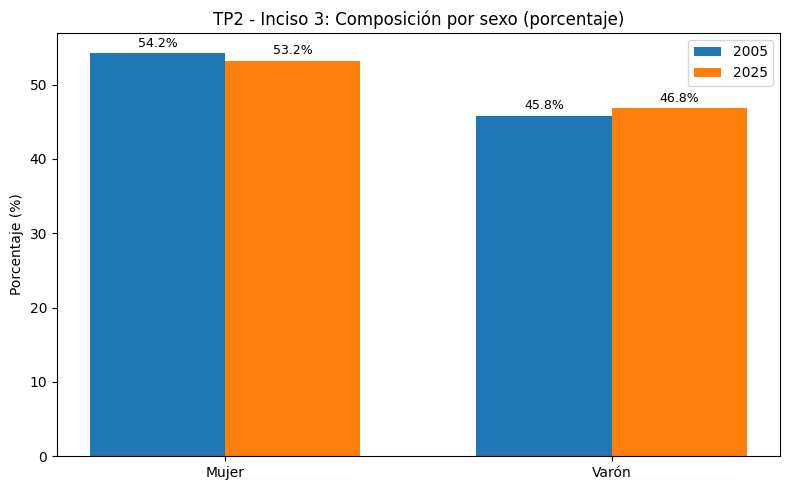

In [99]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



df = pd.read_excel(r"C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\TP2_Intro a EPH\BASES\df_caba_var_limpio.xlsx")
df.columns = [str(c).strip() for c in df.columns]

# Mapear nombres amigables → canónicos si faltan
alias_to_canon = {
    "genero": "CH04",
    "edad": "CH06",
    "parentesco": "CH07",
    "tipo_empleo": "CH08",
    "nivel_educ": "NIVEL_ED",
    "estado_empleo": "ESTADO",
    "categoria_inactividad": "CAT_INAC",
    "ingreso_per_capita": "IPCF",
    "anio": "ANO4",
}
for a, c in alias_to_canon.items():
    if a in df.columns and c not in df.columns:
        df.rename(columns={a: c}, inplace=True)

if "ANO4" in df.columns:
    try:
        df["ANO4"] = df["ANO4"].astype(int)
    except:
        pass

# --------------------------
# INCISO 3 — composición por sexo
# --------------------------
# Normalizar CH04 por si vino como texto
if df["CH04"].dtype == object:
    tmp = df["CH04"].astype(str).str.lower()
    df["CH04"] = np.where(tmp.str.contains("mujer|fem"), 2,
                   np.where(tmp.str.contains("varon|hombre|masc"), 1, np.nan))

sexo_map = {1: "Varón", 2: "Mujer"}
df["SEXO_LABEL"] = df["CH04"].map(sexo_map).fillna("Desconocido")

years_target = [2005, 2025]
available_years = sorted(set(df.get("ANO4", pd.Series([]))).intersection(years_target))
assert len(available_years) > 0, "No hay 2005/2025 en ANO4."

# Conteos y porcentajes
comp_table = (
    df[df["ANO4"].isin(available_years)]
    .groupby(["ANO4","SEXO_LABEL"])
    .size()
    .reset_index(name="cantidad")
)
comp_pivot = comp_table.pivot(index="SEXO_LABEL", columns="ANO4", values="cantidad").fillna(0).astype(int)
comp_pct = comp_pivot.div(comp_pivot.sum(axis=0), axis=1).mul(100)

# Mostrar tablas (para copiar al Word)
print("Inciso 3 — Conteos por sexo")
display(comp_pivot.sort_index())
print("Inciso 3 — Porcentajes por sexo")
display(comp_pct.sort_index().round(2))

# Gráfico (solo display, sin guardar)
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(comp_pct.index))
bar_width = 0.35
if 2005 in comp_pct.columns:
    ax.bar(x - bar_width/2, comp_pct[2005].values, width=bar_width, label="2005")
if 2025 in comp_pct.columns:
    ax.bar(x + bar_width/2, comp_pct[2025].values, width=bar_width, label="2025")

ax.set_xticks(x)
ax.set_xticklabels(comp_pct.index)
ax.set_ylabel("Porcentaje (%)")
ax.set_title("TP2 - Inciso 3: Composición por sexo (porcentaje)")
ax.legend(loc="best")

def autolabel(ax, x_positions, values):
    for xi, val in zip(x_positions, values):
        ax.text(xi, val + 0.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=9)

if 2005 in comp_pct.columns:
    autolabel(ax, x - bar_width/2, np.round(comp_pct[2005].values, 1))
if 2025 in comp_pct.columns:
    autolabel(ax, x + bar_width/2, np.round(comp_pct[2025].values, 1))

plt.tight_layout()
plt.show()



Inciso 4 — Matriz de correlación 2005


,CH06,CH07,CH08,IPCF,CH04_Sexo: Mujer,CH04_Sexo: Varón,NIVEL_ED_Nivel educativo: 1,NIVEL_ED_Nivel educativo: 2,NIVEL_ED_Nivel educativo: 3,NIVEL_ED_Nivel educativo: 4,...,NIVEL_ED_Nivel educativo: 7,ESTADO_Desocupado (2),ESTADO_Inactivo (3),ESTADO_Ocupado (1),CAT_INAC_Estudiante (3),CAT_INAC_Jubilado/Pensionado (1),CAT_INAC_No inactivo (0),CAT_INAC_Otra (7),CAT_INAC_Quehaceres del hogar (4),CAT_INAC_Rentista (5)
CH06,1.000,-0.049,-0.508,0.137,0.083,-0.083,-0.223,0.330,-0.136,0.170,...,-0.336,-0.030,0.215,0.098,-0.508,0.576,0.082,0.013,0.161,-0.384
CH07,-0.049,1.000,-0.001,-0.034,-0.014,0.014,0.001,-0.009,0.064,-0.008,...,-0.024,0.056,-0.055,0.023,-0.010,-0.104,0.066,0.000,0.023,-0.017
CH08,-0.508,-0.001,1.000,-0.060,0.016,-0.016,0.256,-0.215,0.113,-0.189,...,0.232,0.028,0.092,-0.311,0.461,-0.046,-0.289,0.000,-0.246,0.253
IPCF,0.137,-0.034,-0.060,1.000,-0.045,0.045,-0.117,-0.131,-0.138,-0.007,...,-0.060,-0.098,-0.127,0.232,-0.133,0.000,0.180,-0.037,-0.057,-0.071
CH04_Sexo: Mujer,0.083,-0.014,0.016,-0.045,1.000,-1.000,0.032,0.046,-0.062,0.044,...,-0.027,0.015,0.204,-0.194,-0.010,0.072,-0.189,-0.007,0.270,-0.019
CH04_Sexo: Varón,-0.083,0.014,-0.016,0.045,-1.000,1.000,-0.032,-0.046,0.062,-0.044,...,0.027,-0.015,-0.204,0.194,0.010,-0.072,0.189,0.007,-0.270,0.019
NIVEL_ED_Nivel educativo: 1,-0.223,0.001,0.256,-0.117,0.032,-0.032,1.000,-0.142,-0.158,-0.164,...,-0.088,-0.077,0.108,-0.273,0.488,0.017,-0.310,-0.033,-0.072,-0.035
NIVEL_ED_Nivel educativo: 2,0.330,-0.009,-0.215,-0.131,0.046,-0.046,-0.142,1.000,-0.174,-0.180,...,-0.097,-0.025,0.129,-0.034,-0.180,0.229,-0.049,0.003,0.135,-0.097
NIVEL_ED_Nivel educativo: 3,-0.136,0.064,0.113,-0.138,-0.062,0.062,-0.158,-0.174,1.000,-0.201,...,-0.109,0.000,0.213,-0.121,0.270,-0.056,-0.121,0.022,-0.008,-0.108
NIVEL_ED_Nivel educativo: 4,0.170,-0.008,-0.189,-0.007,0.044,-0.044,-0.164,-0.180,-0.201,1.000,...,-0.113,0.064,-0.046,0.102,-0.208,-0.005,0.133,0.075,0.090,-0.112


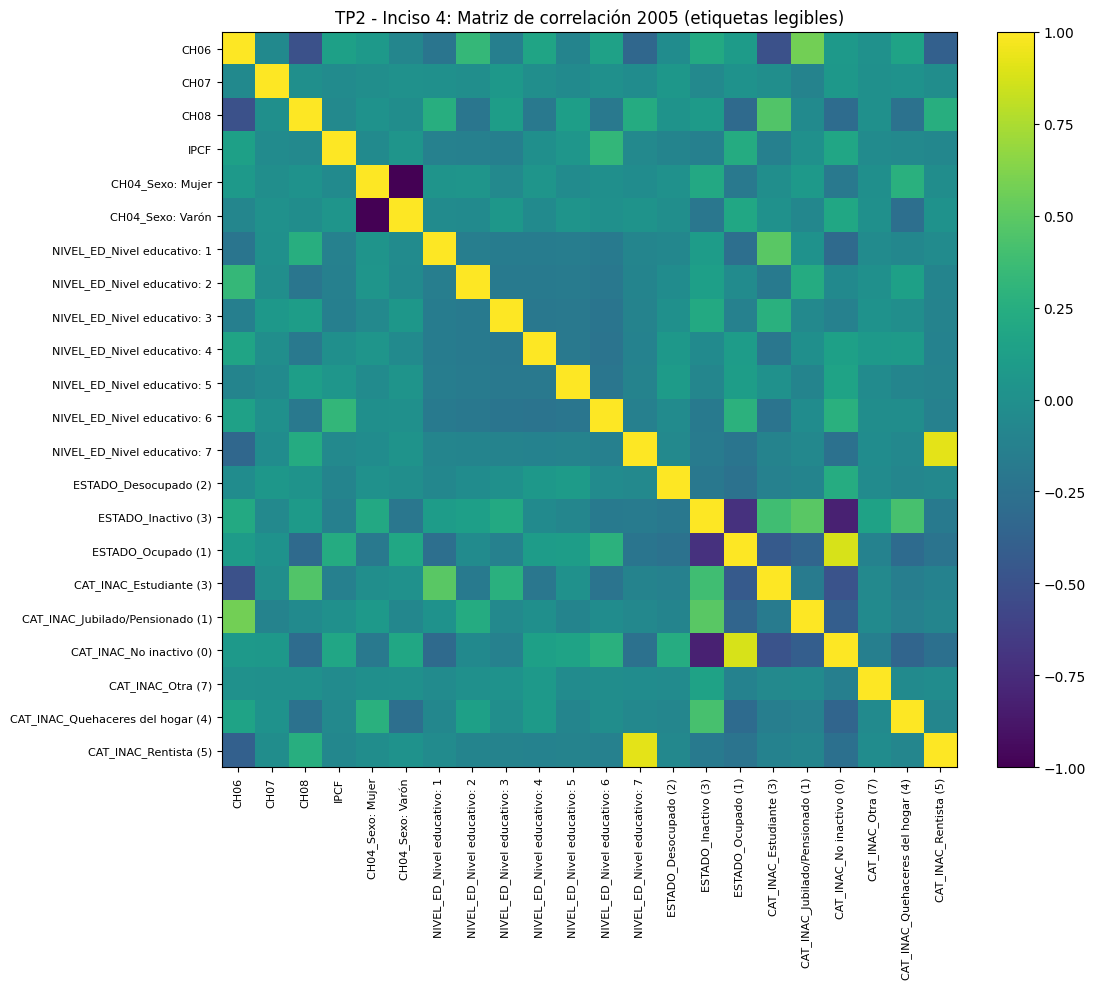


Top correlaciones con IPCF 2005:


,Corr con IPCF (2005)
IPCF,NaN
NIVEL_ED_Nivel educativo: 6,0.322
ESTADO_Ocupado (1),0.232
CAT_INAC_No inactivo (0),0.180
NIVEL_ED_Nivel educativo: 3,-0.138
CH06,0.137



Inciso 4 — Matriz de correlación 2025


,CH06,CH07,CH08,IPCF,CH04_Sexo: Mujer,CH04_Sexo: Varón,NIVEL_ED_Nivel educativo: 1,NIVEL_ED_Nivel educativo: 2,NIVEL_ED_Nivel educativo: 3,NIVEL_ED_Nivel educativo: 4,...,NIVEL_ED_Nivel educativo: 7,ESTADO_Desocupado (2),ESTADO_Inactivo (3),ESTADO_Ocupado (1),CAT_INAC_Estudiante (3),CAT_INAC_Jubilado/Pensionado (1),CAT_INAC_No inactivo (0),CAT_INAC_Otra (7),CAT_INAC_Quehaceres del hogar (4),CAT_INAC_Rentista (5)
CH06,1.000,-0.012,-0.448,-0.016,0.051,-0.051,-0.371,0.229,-0.191,0.184,...,-0.255,-0.036,0.166,0.085,-0.585,0.572,0.072,0.004,0.111,-0.289
CH07,-0.012,1.000,0.040,0.005,0.020,-0.020,0.018,-0.054,0.031,-0.007,...,0.016,0.065,0.010,-0.048,0.010,-0.024,-0.023,-0.011,0.029,0.025
CH08,-0.448,0.040,1.000,0.020,0.032,-0.032,0.266,-0.018,0.168,-0.143,...,0.135,0.017,0.198,-0.341,0.452,-0.064,-0.337,0.072,-0.086,0.163
IPCF,-0.016,0.005,0.020,1.000,-0.040,0.040,-0.052,-0.101,-0.075,-0.104,...,-0.013,-0.087,-0.150,0.183,-0.075,-0.067,0.147,-0.065,-0.056,-0.006
CH04_Sexo: Mujer,0.051,0.020,0.032,-0.040,1.000,-1.000,0.021,0.014,-0.028,0.029,...,-0.011,0.018,0.099,-0.106,-0.030,0.084,-0.103,-0.013,0.140,0.011
CH04_Sexo: Varón,-0.051,-0.020,-0.032,0.040,-1.000,1.000,-0.021,-0.014,0.028,-0.029,...,0.011,-0.018,-0.099,0.106,0.030,-0.084,0.103,0.013,-0.140,-0.011
NIVEL_ED_Nivel educativo: 1,-0.371,0.018,0.266,-0.052,0.021,-0.021,1.000,-0.073,-0.121,-0.140,...,-0.053,-0.063,0.036,-0.291,0.525,-0.092,-0.320,-0.012,-0.017,-0.019
NIVEL_ED_Nivel educativo: 2,0.229,-0.054,-0.018,-0.101,0.014,-0.014,-0.073,1.000,-0.098,-0.114,...,-0.043,0.023,0.103,-0.073,-0.114,0.142,-0.065,0.103,0.086,-0.041
NIVEL_ED_Nivel educativo: 3,-0.191,0.031,0.168,-0.075,-0.028,0.028,-0.121,-0.098,1.000,-0.188,...,-0.071,0.005,0.282,-0.214,0.366,-0.065,-0.215,0.024,-0.018,-0.067
NIVEL_ED_Nivel educativo: 4,0.184,-0.007,-0.143,-0.104,0.029,-0.029,-0.140,-0.114,-0.188,1.000,...,-0.083,0.045,0.035,0.016,-0.218,0.122,0.034,0.025,0.149,-0.078


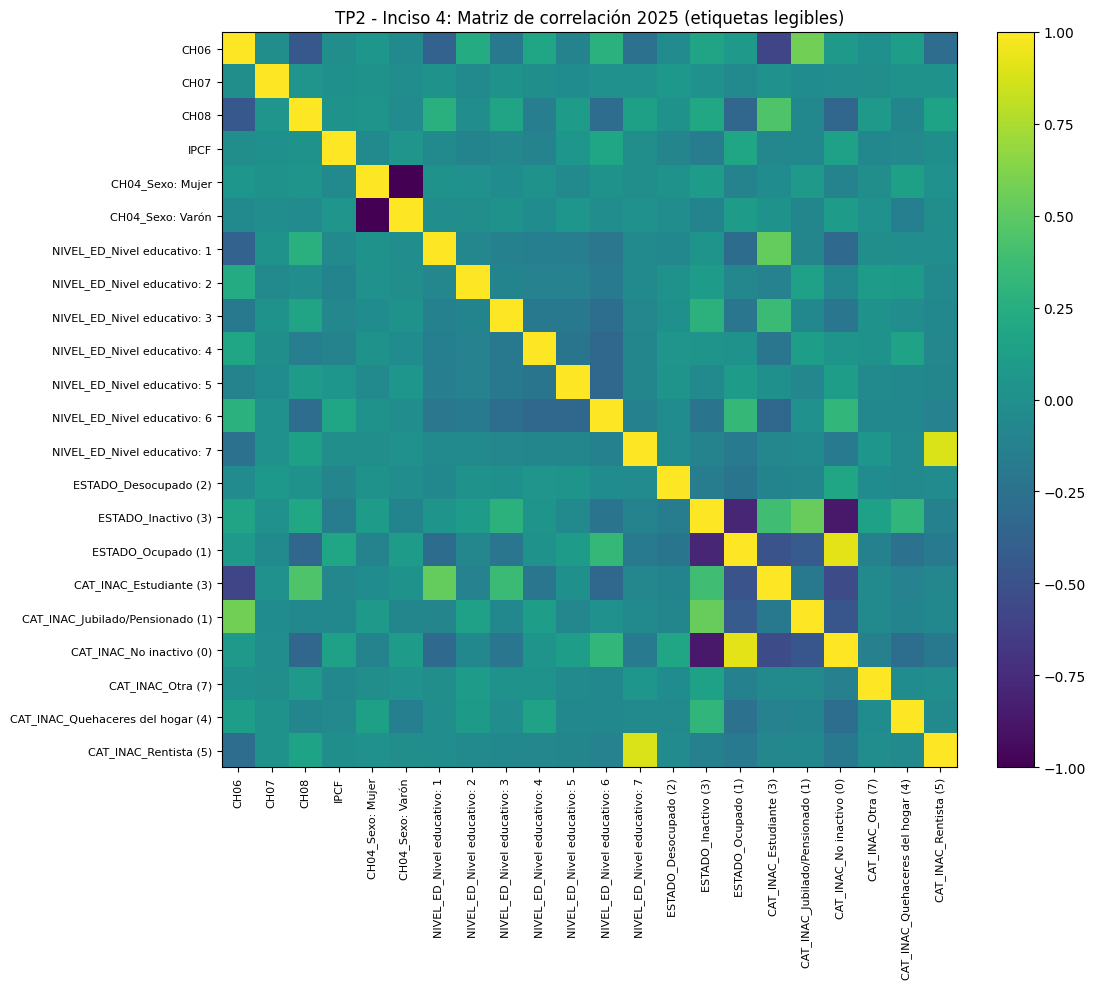


Top correlaciones con IPCF 2025:


,Corr con IPCF (2025)
IPCF,NaN
NIVEL_ED_Nivel educativo: 6,0.186
ESTADO_Ocupado (1),0.183
ESTADO_Inactivo (3),-0.150
CAT_INAC_No inactivo (0),0.147
NIVEL_ED_Nivel educativo: 4,-0.104


In [100]:
# INCISO 4 — matriz de correlación
# --------------------------
vars_interes = ["CH04","CH06","CH07","CH08","NIVEL_ED","ESTADO","CAT_INAC","IPCF","ANO4"]

# Completar canónicas si solo están los alias
if "CH06" not in df.columns and "edad" in df.columns: df["CH06"] = df["edad"]
if "CH07" not in df.columns and "parentesco" in df.columns: df["CH07"] = df["parentesco"]
if "CH08" not in df.columns and "tipo_empleo" in df.columns: df["CH08"] = df["tipo_empleo"]
if "NIVEL_ED" not in df.columns and "nivel_educ" in df.columns: df["NIVEL_ED"] = df["nivel_educ"]
if "ESTADO" not in df.columns and "estado_empleo" in df.columns: df["ESTADO"] = df["estado_empleo"]
if "CAT_INAC" not in df.columns and "categoria_inactividad" in df.columns: df["CAT_INAC"] = df["categoria_inactividad"]
if "IPCF" not in df.columns and "ingreso_per_capita" in df.columns: df["IPCF"] = df["ingreso_per_capita"]

df_sub = df[[c for c in vars_interes if c in df.columns]].copy()

# Etiquetas “humanas” (ajustables si su diccionario difiere)
label_CH04 = {1: "Sexo: Varón", 2: "Sexo: Mujer"}
label_NIVEL_ED = {i: f"Nivel educativo: {i}" for i in range(1,8)}
label_ESTADO = {1: "Ocupado (1)", 2: "Desocupado (2)", 3: "Inactivo (3)"}
label_CAT_INAC = {
    0: "No inactivo (0)", 1: "Jubilado/Pensionado (1)", 3: "Estudiante (3)",
    4: "Quehaceres del hogar (4)", 5: "Rentista (5)", 7: "Otra (7)",
}

df_lab = df_sub.copy()
if "CH04" in df_lab.columns:     df_lab["CH04"]     = df_lab["CH04"].map(label_CH04)
if "NIVEL_ED" in df_lab.columns: df_lab["NIVEL_ED"] = df_lab["NIVEL_ED"].map(label_NIVEL_ED)
if "ESTADO" in df_lab.columns:   df_lab["ESTADO"]   = df_lab["ESTADO"].map(label_ESTADO)
if "CAT_INAC" in df_lab.columns: df_lab["CAT_INAC"] = df_lab["CAT_INAC"].map(label_CAT_INAC)

df_dummies = pd.get_dummies(df_lab, columns=[c for c in ["CH04","NIVEL_ED","ESTADO","CAT_INAC"] if c in df_lab.columns],
                             drop_first=False, dtype=int)

for year in available_years:
    sub = df_dummies[df_dummies["ANO4"] == year].drop(columns=["ANO4"], errors="ignore")
    sub = sub.select_dtypes(include=[np.number])
    if sub.shape[1] < 2 or sub.shape[0] < 5:
        print(f"[Inciso 4] {year}: muestra insuficiente para correlaciones.")
        continue

    corr = sub.corr(numeric_only=True)

    # Para legibilidad: si hay muchísimas columnas, quedarnos con las 35 más asociadas a IPCF
    if "IPCF" in corr.columns and corr.shape[1] > 35:
        keep = corr["IPCF"].abs().sort_values(ascending=False).head(35).index.tolist()
        corr = corr.loc[keep, keep]

    print(f"\nInciso 4 — Matriz de correlación {year}")
    display(corr.round(3))

    # Heatmap solo en pantalla
    fig, ax = plt.subplots(figsize=(12,10))
    cax = ax.imshow(corr.values, interpolation="nearest")
    ax.set_title(f"TP2 - Inciso 4: Matriz de correlación {year} (etiquetas legibles)")
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=8)
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # Top correlaciones con IPCF en consola (para comentario)
    if "IPCF" in corr.columns:
        top = corr["IPCF"].drop(labels=["IPCF"]).dropna().reindex(
            corr["IPCF"].abs().sort_values(ascending=False).head(6).index
        ).to_frame(name=f"Corr con IPCF ({year})")
        print(f"\nTop correlaciones con IPCF {year}:")
        display(top.round(3))

Parte III: Conociendo a los pobres y no pobres


In [90]:
#PARTE 5 corregida
from pathlib import Path
import pandas as pd
import numpy as np

# en este paso detecto el directorio actual
PATH_BASES = Path.cwd()

# en este paso cargo la base directamente
file_path = PATH_BASES / "df_caba_var_limpio.xlsx"
df = pd.read_excel(file_path, dtype="object")

# en este paso preparo la clave de hogar a partir del código de individuo (limpio espacios)
df["hogar_id"] = df["Distincion_vivienda_individuo"].astype(str).str.strip()

# en este paso convierto ingreso a numérico
df["ingreso_per_capita"] = pd.to_numeric(df["ingreso_per_capita"], errors="coerce")

# en este paso calculo cantidad de personas por hogar (y por año si está disponible)
if "anio" in df.columns:
    df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
    n_personas = (
        df.groupby(["anio", "hogar_id"])
          .size()
          .reset_index(name="n_personas")
    )
    df = df.merge(n_personas, on=["anio", "hogar_id"], how="left")
else:
    n_personas = (
        df.groupby(["hogar_id"])
          .size()
          .reset_index(name="n_personas")
    )
    df = df.merge(n_personas, on=["hogar_id"], how="left")

# en este paso aseguro que n_personas sea numérica
df["n_personas"] = pd.to_numeric(df["n_personas"], errors="coerce")

# en este paso calculo ITF como ingreso per cápita multiplicado por cantidad de personas del hogar
df["ITF"] = df["ingreso_per_capita"] * df["n_personas"]

# en este paso cuento personas sin respuesta en condición de actividad
no_respondieron_cond_actividad = df["estado_empleo"].isna().sum()

# en este paso separo respondieron y norespondieron según ITF
respondieron = df[(~df["ITF"].isna()) & (df["ITF"] > 0)].copy()
norespondieron = df[df["ITF"].fillna(0) == 0].copy()

# en este paso guardo resultados en BASES
respondieron.to_excel(PATH_BASES / "respondieron.xlsx", index=False)
norespondieron.to_excel(PATH_BASES / "norespondieron.xlsx", index=False)

print("Personas sin respuesta en condición de actividad:", int(no_respondieron_cond_actividad))
print("Observaciones en respondieron:", respondieron.shape[0])
print("Observaciones en norespondieron:", norespondieron.shape[0])
print("Archivos guardados en:", PATH_BASES)


Personas sin respuesta en condición de actividad: 8
Observaciones en respondieron: 3257
Observaciones en norespondieron: 546
Archivos guardados en: C:\Users\War\Desktop\BigDatayML\BigDataUBA-Grupo-4\TP 2\BASES


In [95]:
#PARTE 6

import pandas as pd
import numpy as np
import re
from pathlib import Path

# carpeta BASES
PATH_BASES = Path.cwd()

# archivos de entrada
file_resp = PATH_BASES / "respondieron.xlsx"
file_ae   = PATH_BASES / "tabla_adulto_equiv.xlsx"

# cargo la base respondieron
df = pd.read_excel(file_resp)

# normalizo edad
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")

# normalizo genero a etiquetas 'Mujeres' / 'Varones'
def normalizar_genero_etiqueta(s):
    s2 = s.astype(str).str.strip().str.lower()
    mapear = {
        "mujer":"Mujeres","femenino":"Mujeres","female":"Mujeres","f":"Mujeres","2":"Mujeres","2.0":"Mujeres",
        "varon":"Varones","varón":"Varones","hombre":"Varones","masculino":"Varones","male":"Varones","m":"Varones","1":"Varones","1.0":"Varones"
    }
    return s2.map(mapear)

df["sexo_label"] = normalizar_genero_etiqueta(df["genero"])

# cargo la tabla AE
raw = pd.read_excel(file_ae, header=None)
header_row = raw.index[raw.apply(lambda r: r.astype(str).str.contains(r"(?i)^edad$").any(), axis=1)].tolist()
ae = pd.read_excel(file_ae, header=header_row[0])
ae = ae.rename(columns={ae.columns[0]:"Edad_txt", ae.columns[1]:"Mujeres", ae.columns[2]:"Varones"})

# convierto comas a puntos y a float
for col in ["Mujeres","Varones"]:
    ae[col] = (ae[col].astype(str)
                      .str.replace(",", ".", regex=False)
                      .str.replace(r"[^\d\.]", "", regex=True)
                      .replace({"": np.nan})
                      .astype(float))

# parseo rangos de edad
def parse_rango(t):
    t = str(t).strip().lower().replace("años","").replace("año","").strip()
    if t.startswith("más de") or t.startswith("mas de"):
        m = re.search(r"(\d+)", t)
        if m: return int(m.group(1))+1, 120
    m = re.match(r"^(\d+)\s*a\s*(\d+)$", t)
    if m: return int(m.group(1)), int(m.group(2))
    m = re.match(r"^(\d+)$", t)
    if m: return int(m.group(1)), int(m.group(1))
    return None, None

ae[["edad_lo","edad_hi"]] = ae["Edad_txt"].apply(lambda x: pd.Series(parse_rango(x)))
ae = ae.dropna(subset=["edad_lo","edad_hi"])

# expando a edades enteras
rows = []
for _, r in ae.iterrows():
    lo, hi = int(r["edad_lo"]), int(r["edad_hi"])
    for e in range(lo, hi+1):
        rows.append({"edad": e, "Mujeres": r["Mujeres"], "Varones": r["Varones"]})
ae_long = pd.DataFrame(rows)

# paso a formato largo (esta es la línea corregida)
ae_long = ae_long.melt(id_vars="edad", value_vars=["Mujeres", "Varones"],
                       var_name="sexo_label", value_name="adulto_equiv")

# mergeo con la base respondieron
df = df.merge(ae_long, on=["edad","sexo_label"], how="left")

# limpio columnas duplicadas si quedaron
if "adulto_equiv_x" in df.columns:
    df = df.rename(columns={"adulto_equiv_x": "adulto_equiv"})
if "adulto_equiv_y" in df.columns:
    df = df.drop(columns=["adulto_equiv_y"])

# en este paso convierto adulto_equiv a numérico
df["adulto_equiv"] = pd.to_numeric(df["adulto_equiv"], errors="coerce")

# en este paso defino la clave de hogar unica a partir del codigo largo
df["hogar_id"] = df["Distincion_vivienda_individuo"].astype(str).str.strip()

# en este paso elijo la columna de adulto equivalente segun exista
col_adulto = "adulto_equiv" if "adulto_equiv" in df.columns else "adulto_equivalente"

# en este paso convierto adulto equivalente a numerico
df[col_adulto] = pd.to_numeric(df[col_adulto], errors="coerce")

# en este paso sumo adulto equivalente por hogar unico
if "anio" in df.columns:
    df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
    df["ad_equiv_hogar"] = (
        df.groupby(["anio", "hogar_id"])[col_adulto]
          .transform("sum")
    )
else:
    df["ad_equiv_hogar"] = (
        df.groupby("hogar_id")[col_adulto]
          .transform("sum")
    )

# en este paso hago un chequeo rapido
print(df[["hogar_id", col_adulto, "ad_equiv_hogar"]].head())



# guardo el resultado sobrescribiendo respondieron.xlsx
df.to_excel(file_resp, index=False)

print("Listo. Se agregaron 'adulto_equiv' y 'ad_equiv_hogar' en respondieron.xlsx")




  hogar_id  adulto_equiv  ad_equiv_hogar
0   125098          0.74            0.74
1   125188          1.02            1.78
2   125188          0.76            1.78
3   125188           NaN            1.78
4   125242          0.67            0.67
Listo. Se agregaron 'adulto_equiv' y 'ad_equiv_hogar' en respondieron.xlsx


In [102]:
# PARTE 7 - Agregar ingreso_necesario (corregida)
import pandas as pd
from pathlib import Path
import numpy as np

# carpeta BASES
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# cargo la base respondieron actualizada (con ad_equiv_hogar)
df = pd.read_excel(file_resp)

# defino valores de CBT por adulto equivalente
CBT_MAP = {
    2005: 205.07,
    2025: 365177.0
}

# creo columna ingreso_necesario (CBT * adulto_equivalente del hogar)
df["ingreso_necesario"] = df.apply(
    lambda row: row["ad_equiv_hogar"] * CBT_MAP.get(int(row["anio"]), np.nan),
    axis=1
)

# guardo sobrescribiendo la base respondieron.xlsx
df.to_excel(file_resp, index=False)

print("Listo. Se agregó la columna 'ingreso_necesario' en respondieron.xlsx")


Listo. Se agregó la columna 'ingreso_necesario' en respondieron.xlsx


In [103]:
#parte 8
# en este paso importo librerias
from pathlib import Path
import pandas as pd
import numpy as np

# en este paso fijo carpeta
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo respondieron
respondieron = pd.read_excel(file_resp, dtype="object")

# en este paso tipifico variables necesarias
respondieron["anio"] = pd.to_numeric(respondieron.get("anio"), errors="coerce")
respondieron["ITF"] = pd.to_numeric(respondieron.get("ITF"), errors="coerce")
respondieron["ingreso_necesario"] = pd.to_numeric(respondieron.get("ingreso_necesario"), errors="coerce")

# en este paso creo la columna pobre segun la consigna
respondieron["pobre"] = (respondieron["ITF"] < respondieron["ingreso_necesario"]).astype("Int64")

# en este paso calculo resumen por año
resumen = (
    respondieron
    .groupby("anio", dropna=False)
    .agg(
        pobres=("pobre", lambda s: pd.to_numeric(s, errors="coerce").fillna(0).sum()),
        total=("pobre", "size")
    )
    .assign(porcentaje=lambda d: (d["pobres"] / d["total"] * 100).round(2))
    .reset_index()
    .sort_values("anio")
)

# en este paso guardo la base actualizada
respondieron.to_excel(file_resp, index=False)

# en este paso muestro resultados pedidos
print("Pobres identificados y porcentaje sobre la muestra por año")
print(resumen.to_string(index=False))



Pobres identificados y porcentaje sobre la muestra por año
 anio  pobres  total  porcentaje
 2005     228   2328        9.79
 2025     127    929       13.67


Estadísticas descriptivas de pobreza por año
 anio  pobres  no_pobres  total  tasa_pobreza
 2005     228       2100   2328          9.79
 2025     127        802    929         13.67


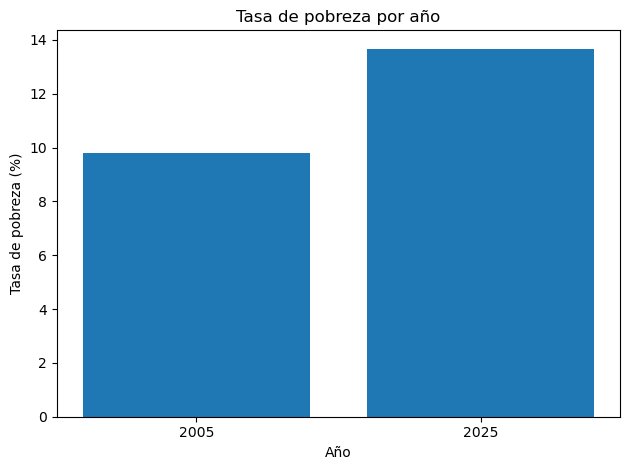

<Figure size 640x480 with 0 Axes>

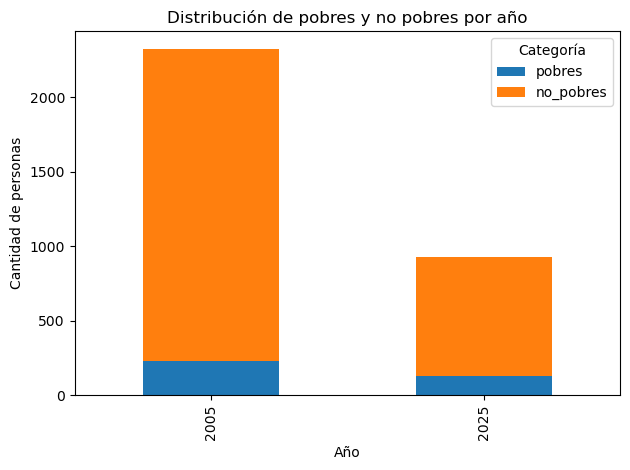

In [105]:
#PARTE 9
# importo librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# cargo la base
df = pd.read_excel(file_resp, dtype="object")

# tipifico variables que uso
df["anio"] = pd.to_numeric(df.get("anio"), errors="coerce")
df["pobre"] = pd.to_numeric(df.get("pobre"), errors="coerce")

# filtro solo 2005 y 2025
df_comp = df[df["anio"].isin([2005, 2025])].copy()

# verifico que pobre sea 0 o 1
df_comp["pobre"] = df_comp["pobre"].fillna(0).clip(0, 1)

# armo tabla de estadísticas descriptivas relevantes por año
resumen = (
    df_comp
    .groupby("anio", dropna=False)
    .agg(
        pobres=("pobre", "sum"),
        no_pobres=("pobre", lambda s: s.size - s.sum()),
        total=("pobre", "size"),
        tasa_pobreza=("pobre", "mean")
    )
    .assign(tasa_pobreza=lambda d: (d["tasa_pobreza"] * 100).round(2))
    .reset_index()
    .sort_values("anio")
)

# muestro tabla en consola
print("Estadísticas descriptivas de pobreza por año")
print(resumen.to_string(index=False))

# guardo la tabla a excel por si necesito reportarla
out_path = PATH_BASES / "resumen_pobre_2005_2025.xlsx"
resumen.to_excel(out_path, index=False)

# hago gráfico 1: barra de tasa de pobreza por año
plt.figure()
plt.bar(resumen["anio"].astype(str), resumen["tasa_pobreza"])
plt.title("Tasa de pobreza por año")
plt.xlabel("Año")
plt.ylabel("Tasa de pobreza (%)")
plt.tight_layout()
plt.show()

# preparo datos para gráfico 2: barras apiladas de pobres vs no pobres por año
base_stacked = resumen.set_index("anio")[["pobres", "no_pobres"]]

# hago gráfico 2: barras apiladas de conteos
plt.figure()
base_stacked.plot(kind="bar", stacked=True)
plt.title("Distribución de pobres y no pobres por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de personas")
plt.legend(title="Categoría")
plt.tight_layout()
plt.show()
